# Definitions

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/roman_real/interface):
# the probe, chi2, response, Fisher, and bfmt wrappers every notebook
# of this project shares
import cosmolike_roman_real_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils


In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="3x2pt"

path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ggl_exclude=[[6,0],[7,0],[7,1]]

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
lmax = 100000


# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(lmax=lmax,
             ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

In [ ]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_roman_real_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_roman_real_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    roman_A1_1, roman_A1_2,
    roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4,
    roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8,
    roman_M1, roman_M2, roman_M3, roman_M4,
    roman_M5, roman_M6, roman_M7, roman_M8,
    roman_DZ_L1, roman_DZ_L2, roman_DZ_L3, roman_DZ_L4,
    roman_DZ_L5, roman_DZ_L6, roman_DZ_L7, roman_DZ_L8,
    roman_B1_1, roman_B1_2, roman_B1_3, roman_B1_4,
    roman_B1_5, roman_B1_6, roman_B1_7, roman_B1_8,
    roman_PM1, roman_PM2, roman_PM3, roman_PM4,
    roman_PM5, roman_PM6, roman_PM7, roman_PM8)

In [5]:
# get_camb_cosmology lives in cosmolike_core, shared by every project's
# notebooks; call it as cnu.get_camb_cosmology (imported above). It
# scales the chi(z) node count with the CAMB boost (1625 nodes at
# boost 1). The nw wrappers hand it kmax explicitly; each wrapper's
# signature gives its default.

In [ ]:
# C_gs_tomo_limber lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_gs_tomo_limber.

In [ ]:
# C_gg_tomo lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_gg_tomo.

In [ ]:
# gamma_t lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.gamma_t.

In [ ]:
# w_theta lives in this project's interface/
# (cosmolike_roman_real_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.w_theta.

In [10]:
# plot_C_gs_tomo_limber lives in cosmolike_core (shared); call it as
# cnu.plot_C_gs_tomo_limber (imported above). Its panel grid has one
# row per source bin and one column per lens bin, for any lens and
# source bin counts.


In [11]:
# plot_C_gg_tomo lives in cosmolike_core (shared); call it as
# cnu.plot_C_gg_tomo (imported above)


In [12]:
# plot_gammat_tomo_limber lives in cosmolike_core (shared); call it
# as cnu.plot_gammat_tomo_limber (imported above). Its panel grid has
# one row per source bin and one column per lens bin, for any lens
# and source bin counts; thetashow sets the x range.


In [13]:
# plot_wtheta_tomo lives in cosmolike_core (shared); call it as
# cnu.plot_wtheta_tomo (imported above)


In [ ]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike()
allsims = nw.allsims

# Let's plot how cosmological and nuisance parameters affect $C_{\ell}^{gs}$

In [15]:
ell = np.arange(25., 2500., 3.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, omegam=x))

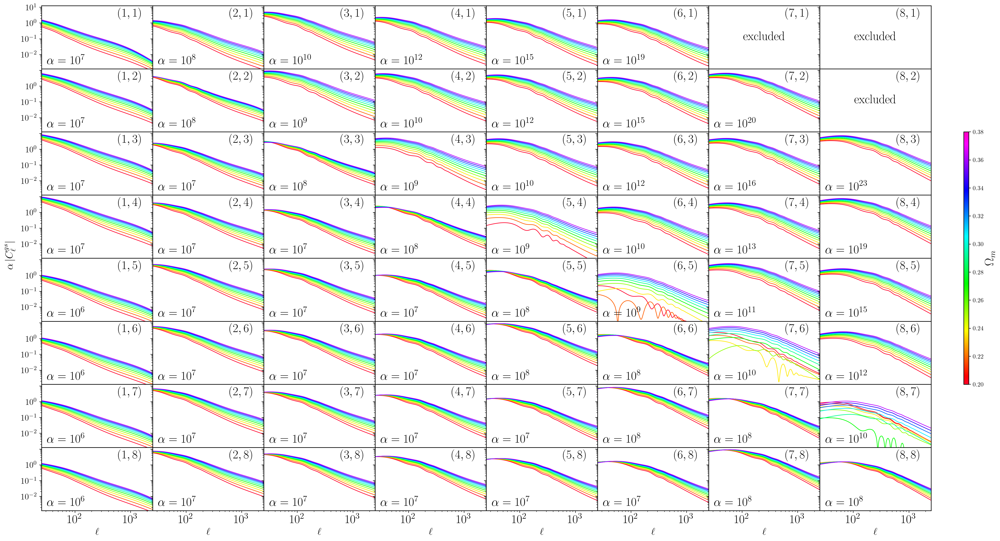

In [16]:
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs = np.abs(C_gs),
                          param = param,
                          colorbarlabel = "$\Omega_m$",
                          bintextpos = [0.8, 0.875],
                          ylim = [0.75,1.3],
                          lmin = ell[0],
                          lmax = ell[len(ell)-1],
                          figsize = (32, 15),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20,
                          rescale=1,
                          ydecades=4)

In [17]:
ell = np.arange(25., 2500., 3.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, ns=x))

# Plot the Ratio over ref cosmology
ref = nw.C_gs_tomo_limber(ell=ell)

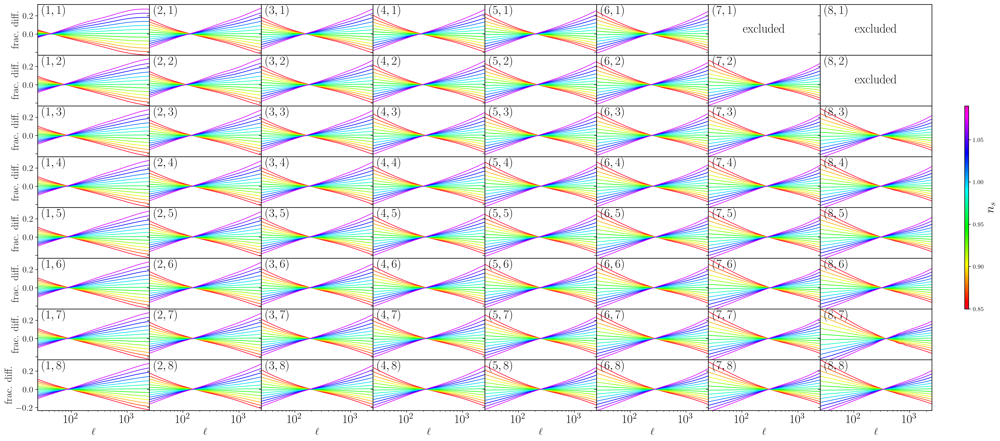

In [18]:
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs=C_gs,
                          C_gs_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          bintextpos = [0.15, 0.875],
                          ylim = [0.77,1.325],
                          lmin=ell[0],
                          lmax=ell[len(ell)-1],
                          figsize = (32, 12),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

# Let's plot how cosmological and nuisance parameters affect $\gamma_t(\theta)$

In [19]:
param = np.arange(0.2, 0.4, 0.02)   
gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(omegam = x))

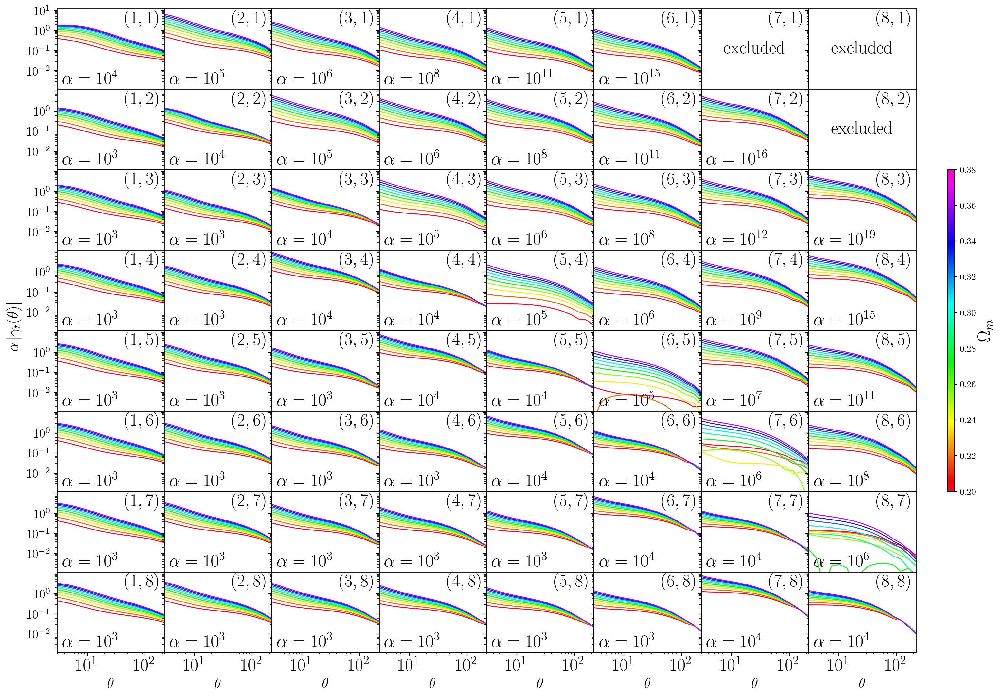

In [20]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            gammat_ref = None,
                            param = param,
                            colorbarlabel = "$\Omega_m$",
                            bintextpos = [0.8, 0.875],
                            ylim = [0.75,1.3],
                            figsize = (21, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

# Can we change the binning on $\gamma_t(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache internal variables

In [21]:
nthetas=[9, 12, 17, 44]
gammat_theta = []
for x in nthetas:
    gammat_theta.append(nw.gamma_t(ntheta=x))

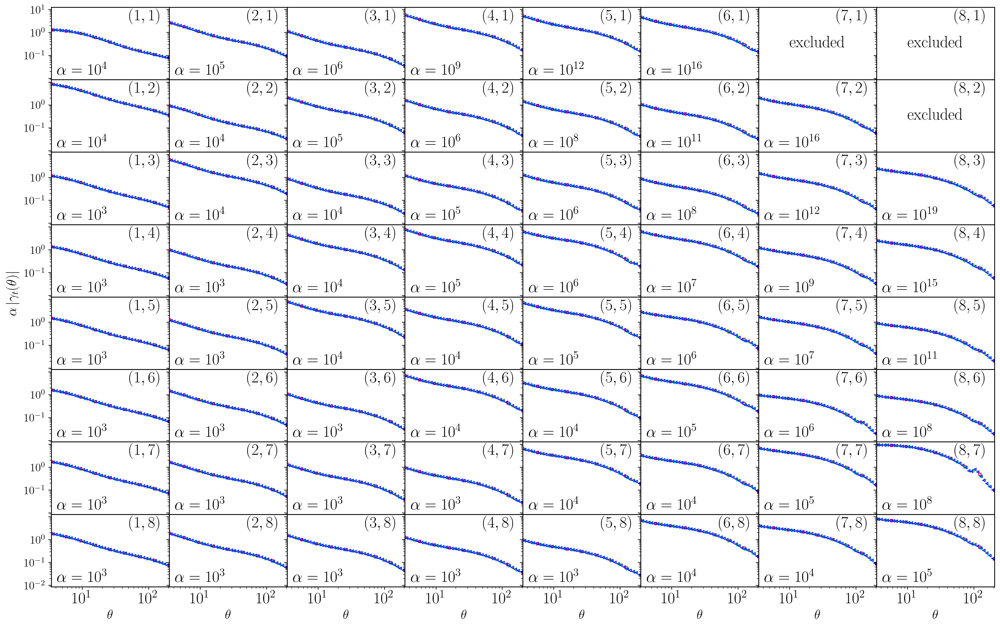

In [22]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            marker=['s', 'o', ">", "<"],
                            ylim = [0.75,1.3],
                            bintextpos = [0.8, 0.875],
                            figsize = (21, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

In [23]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
    
C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell,baryon_sims=x))
    
# Plot the Ratio over ref cosmology
C_gs_ref = nw.C_gs_tomo_limber(ell=ell)

gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))
gammat_theta_ref = nw.gamma_t(ntheta=40, AccuracyBoost=1.0)

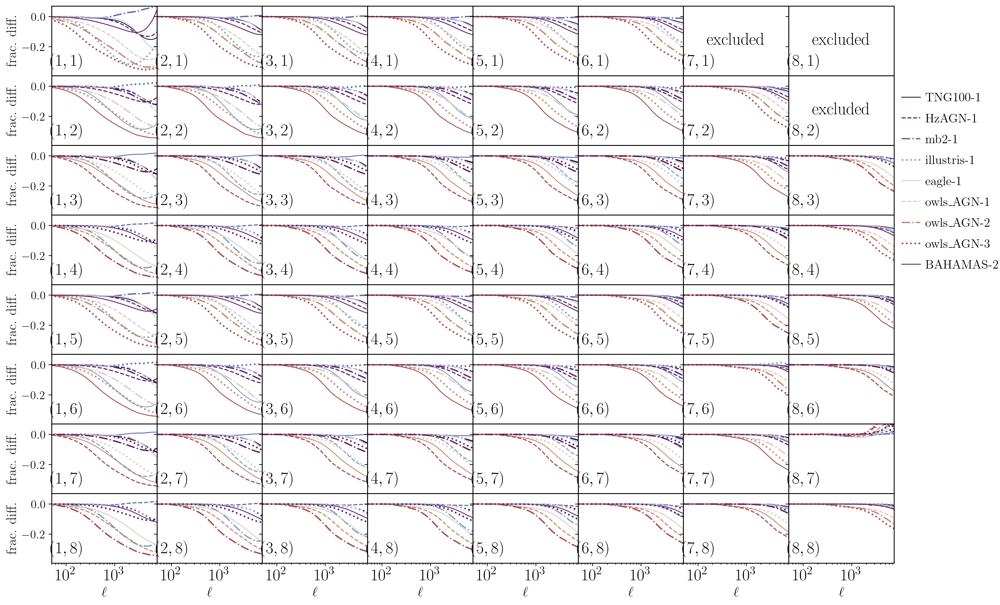

In [24]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gs_tomo_limber(ell=ell,
                          C_gs=C_gs,
                          C_gs_ref=C_gs_ref,
                          lmin=50,
                          lmax=ell[len(ell)-1],
                          cmap="twilight_shifted",
                          bintextpos = [0.15, 0.2],
                          ylim = [0.61,1.07],
                          legend = param,
                          legendloc=(0.9,0.55),
                          linewidth=[1.0, 1.3, 1.6, 1.9],
                          linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                          figsize = (18, 12),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20)

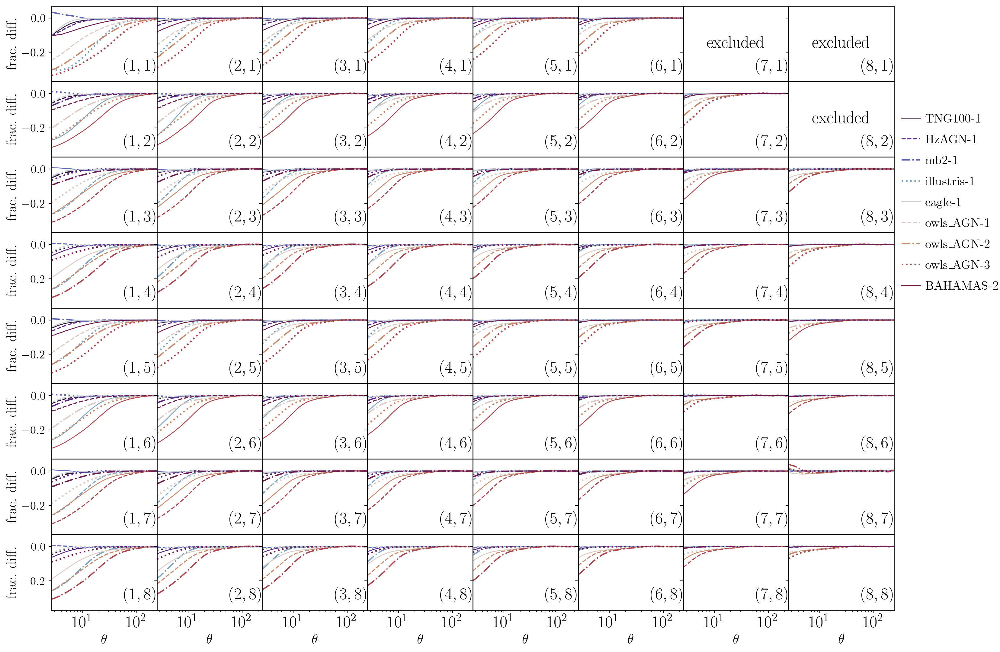

In [25]:
cnu.plot_gammat_tomo_limber(theta_gammat=gammat_theta,
                            gammat_ref=gammat_theta_ref,
                            cmap="twilight_shifted",
                            bintextpos = [0.85, 0.2],
                            ylim = [0.63,1.07],
                            legend = param,
                            legendloc=(0.9,0.55),
                            linewidth=[1.0, 1.3, 1.6, 1.9],
                            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                            figsize = (18, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20)

# Check how CAMB and Cosmolike Accuracy Boost affect $C_\ell^{\rm gs}$ and $\gamma_t(\theta)$ data vectors

In [26]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)

param = np.arange(0,6.0,0.5)

C_gs = []
for x in param:
    C_gs.append(nw.C_gs_tomo_limber(ell=ell, AccuracyBoost=1.0,CAMBAccuracyBoost=1.+x/3.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
    
# Plot the Ratio over ref cosmology
C_gs_ref = nw.C_gs_tomo_limber(ell = ell,
                            AccuracyBoost = 1.0,
                            CAMBAccuracyBoost = 1.,
                            CLAccuracyBoost=1,CLIntegrationAccuracy=0)

gammat_theta = []
for x in param:
    gammat_theta.append(nw.gamma_t(ntheta = 40,
                        AccuracyBoost = 1.0,
                        CAMBAccuracyBoost = 1. + x/3.,
                        CLAccuracyBoost = 1+x,
                        CLIntegrationAccuracy=int(x))
                       )
gammat_theta_ref = nw.gamma_t(ntheta = 40,
                           AccuracyBoost = 1.0,
                           CAMBAccuracyBoost = 1.,
                           CLAccuracyBoost = 1,
                           CLIntegrationAccuracy = 0)

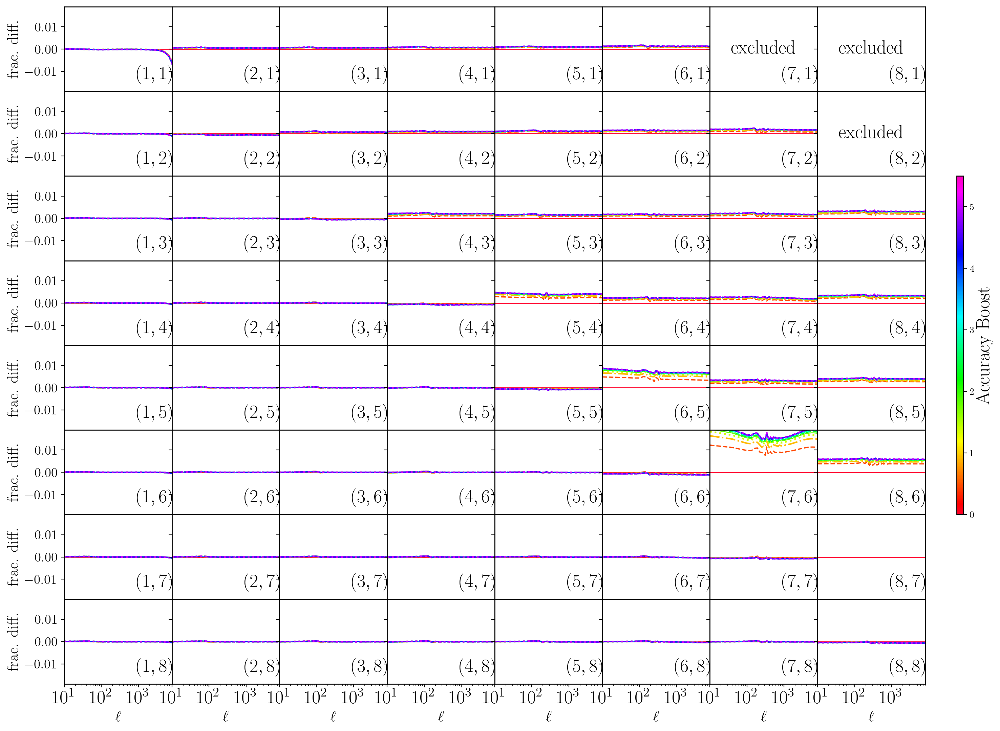

In [27]:
cnu.plot_C_gs_tomo_limber(ell = ell,
                          C_gs = C_gs,
                          C_gs_ref = C_gs_ref,
                          param = param,
                          lmin = 10,
                          lmax = 8000,
                          ylim = (0.981,1.019),
                          bintextpos = [0.85, 0.2],
                          colorbarlabel="Accuracy Boost",
                          linewidth=[1.0, 1.3, 1.6, 1.9],
                          linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                          figsize = (20, 13),
                          bintextsize = 20,
                          yaxislabelsize = 17,
                          yaxisticklabelsize = 14,
                          xaxisticklabelsize = 20,
                          rescale=1,
                          ydecades=4)

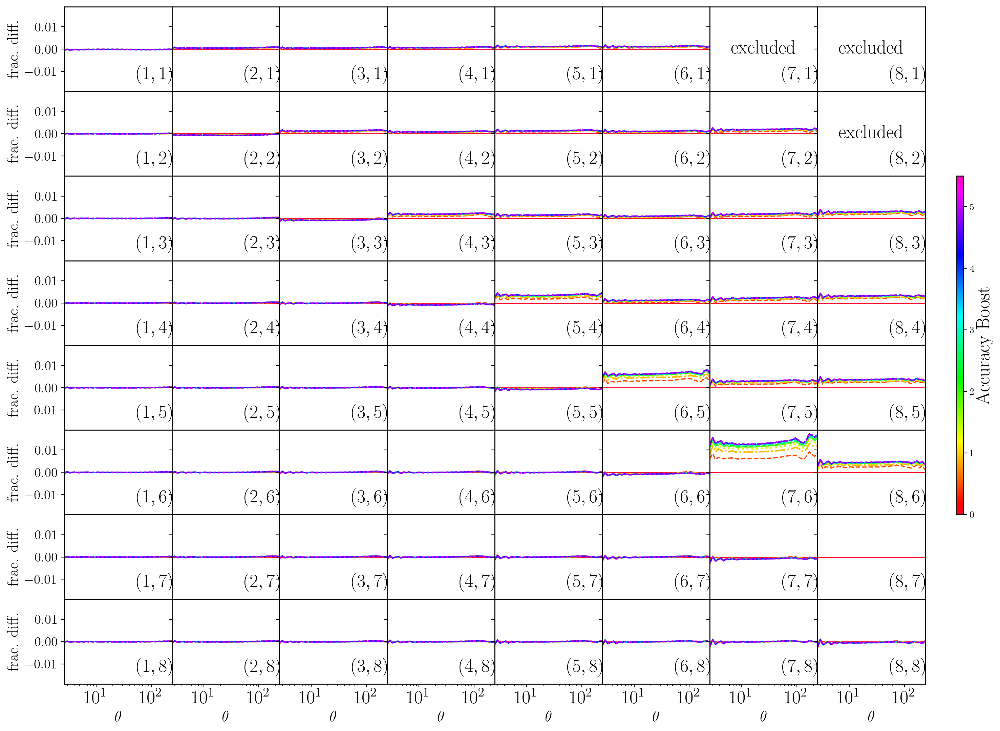

In [28]:
cnu.plot_gammat_tomo_limber(theta_gammat = gammat_theta,
                            gammat_ref = gammat_theta_ref,
                            bintextpos = [0.85, 0.2],
                            ylim = (0.981,1.019),
                            param = param,
                            legendloc = (0.9,0.55),
                            colorbarlabel="Accuracy Boost",
                            linewidth=[1.0, 1.3, 1.6, 1.9],
                            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                            figsize = (20, 13),
                            bintextsize = 20,
                            yaxislabelsize = 17,
                            yaxisticklabelsize = 14,
                            xaxisticklabelsize = 20,
                            rescale=1,
                            ydecades=4)

# Let's plot how cosmological and nuisance parameters affect $C_{\ell}^{gg}$ (Non-Limber/Limber)

In [29]:
ell = np.arange(3., 2500., 3.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
C_gg_L = []
C_gg_NL = []
ratio = []
for x in param:
    tmp1 = nw.C_gg_tomo(ell=ell, limber=1, omegam=x)
    tmp2 = nw.C_gg_tomo(ell=ell, limber=0, omegam=x)
    C_gg_L.append(tmp1)
    C_gg_NL.append(tmp2)

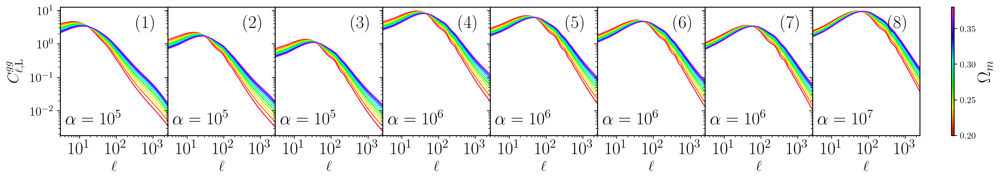

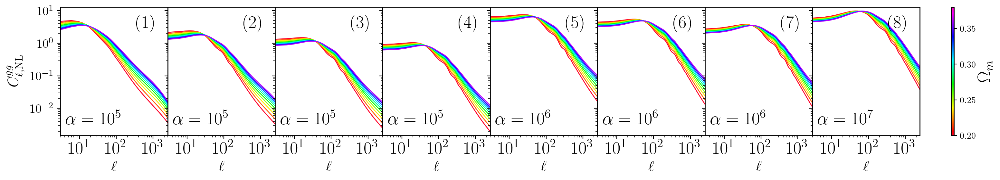

In [30]:
cnu.plot_C_gg_tomo(ell = ell,
                   C_gg = C_gg_L,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.75,1.3],
                   lmin = ell[0],
                   lmax = ell[len(ell)-1],
                   overwriteylabel = "$C_{\ell,{\\rm L}}^{gg}$",
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)
cnu.plot_C_gg_tomo(ell = ell,
                   C_gg = C_gg_NL,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.75,1.3],
                   lmin = ell[0],
                   lmax = ell[len(ell)-1],
                   overwriteylabel = "$C_{\ell,{\\rm NL}}^{gg}$",
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)

In [31]:
ell = np.arange(3., 250., 1.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)
ratio = []
for x in param:
    tmp1 = nw.C_gg_tomo(ell=ell, limber=1, omegam=x)
    tmp2 = nw.C_gg_tomo(ell=ell, limber=0, omegam=x)
    ratio.append(tmp2/tmp1)

/var/folders/8m/fbnlt6rs00g8g5nshfw27mfw0000gn/T/ipykernel_53454/2098546462.py:7: RuntimeWarning: invalid value encountered in divide
  ratio.append(tmp2/tmp1)


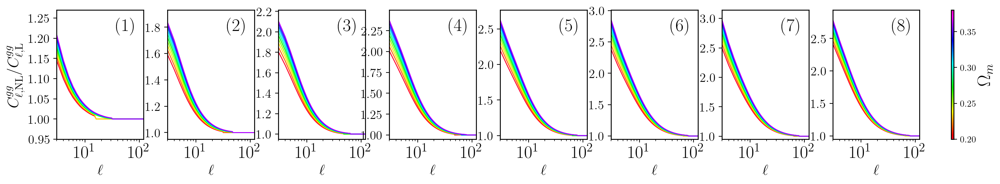

In [32]:
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=ratio,
                   param = param,
                   colorbarlabel = "$\Omega_m$",
                   bintextpos = [0.8, 0.875],
                   ylim = [0.95,1.05],
                   lmin = 3,
                   lmax = 120,
                   forcelinearyscale = True,
                   overwriteylabel = "$C_{\ell,{\\rm NL}}^{gg}/C_{\ell,{\\rm L}}^{gg}$",
                   forcelinearxscale = False,
                   marker = None,
                   figsize = (21, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20)

# Let's plot how cosmological and nuisance parameters affect $w(\theta)$

In [33]:
param = np.arange(0.2, 0.4, 0.02)   
wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(omegam = x))

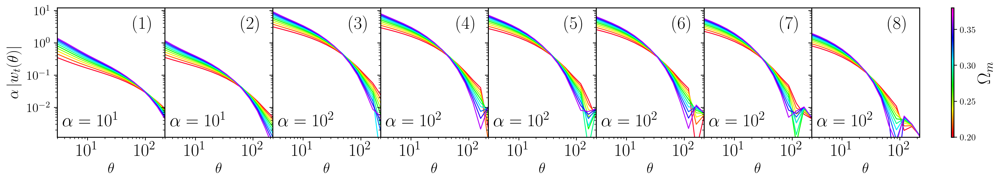

In [34]:
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     theta_wtheta_ref = None,
                     param = param,
                     colorbarlabel = "$\Omega_m$",
                     bintextpos = [0.8, 0.875],
                     ylim = [0.75,1.3],
                     figsize = (21, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     rescale=1,
                     ydecades=4)

# Can we change the binning on $w(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache internal variables

In [35]:
nthetas=[9, 12, 17, 44]
wtheta_theta = []
for x in nthetas:
    wtheta_theta.append(nw.w_theta(ntheta=x))

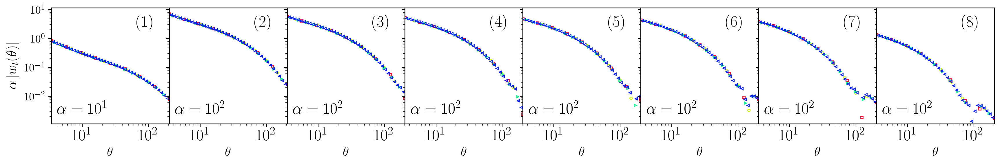

In [36]:
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     marker = ['s', 'o', ">", "<"],
                     ylim = [0.75,1.3],
                     bintextpos = [0.8, 0.875],
                     figsize = (21, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     rescale=1,
                     ydecades=4)

In [37]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
    
C_gg = []
for x in param:
    C_gg.append(nw.C_gg_tomo(ell=ell,limber=False,baryon_sims=x))
    
# Plot the Ratio over ref cosmology
C_gg_ref = nw.C_gg_tomo(ell=ell,limber=False)

wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))
wtheta_theta_ref = nw.w_theta(ntheta=40, AccuracyBoost=1.0)

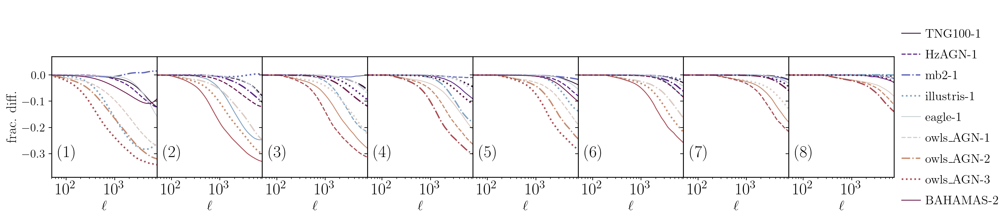

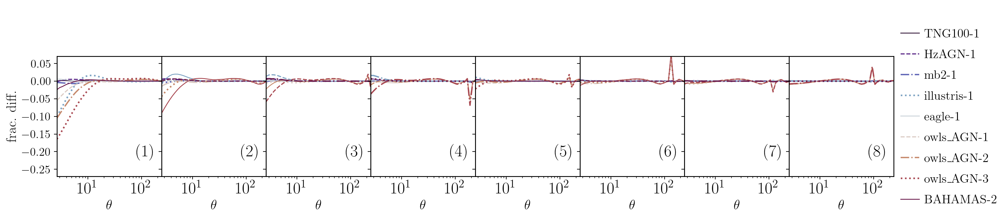

In [38]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=C_gg,
                   C_gg_ref=C_gg_ref,
                   lmin=50,
                   lmax=ell[len(ell)-1],
                   cmap="twilight_shifted",
                   bintextpos = [0.15, 0.2],
                   ylim = [0.61,1.07],
                   legend = param,
                   legendloc=(0.9,0.05),
                   linewidth=[1.0, 1.3, 1.6, 1.9],
                   linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                   figsize = (18, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20)
cnu.plot_wtheta_tomo(theta_wtheta=wtheta_theta,
                     theta_wtheta_ref=wtheta_theta_ref,
                     cmap="twilight_shifted",
                     bintextpos = [0.85, 0.2],
                     ylim = [0.73,1.07],
                     legend = param,
                     legendloc=(0.9,0.05),
                     linewidth=[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20)

# Check how CAMB and Cosmolike Accuracy Boost affect $C_\ell^{\rm gg}$ and $w(\theta)$ data vectors

In [39]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.6,6.0,0.5)
C_gg = []
for x in param:
    C_gg.append(nw.C_gg_tomo(ell=ell,limber=False,AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
    
# Plot the Ratio over ref cosmology
C_gg_ref = nw.C_gg_tomo(ell=ell,limber=False,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

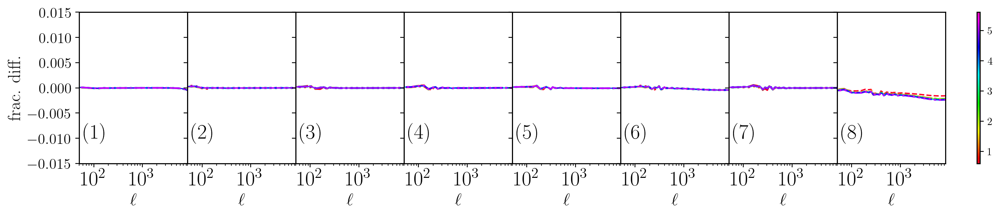

In [40]:
matplotlib.rcParams['legend.fontsize'] = 15
cnu.plot_C_gg_tomo(ell=ell,
                   C_gg=C_gg,
                   C_gg_ref=C_gg_ref,
                   lmin=50,
                   lmax=ell[len(ell)-1],
                   bintextpos = [0.15, 0.2],
                   ylim = [0.985,1.015],
                   param = param,
                   legendloc = (0.9,0.05),
                   linewidth =[1.0, 1.3, 1.6, 1.9],
                   linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                   figsize = (18, 13./5),
                   bintextsize = 20,
                   yaxislabelsize = 17,
                   yaxisticklabelsize = 14,
                   xaxisticklabelsize = 20,
                   rescale=1,
                   ydecades=4)

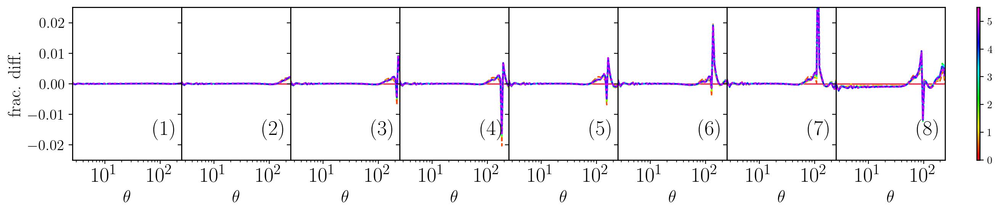

In [41]:
# HERE WE LEARN THAT FOR W(THETA), CAMB SHOULD HAVE ACCURACY BOOST=1.2
param = np.arange(0,6.0,0.5)

wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2+x/3,CLAccuracyBoost=1.0+x,CLIntegrationAccuracy=int(x)))
wtheta_theta_ref = nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1.0,CLIntegrationAccuracy=0)
  
cnu.plot_wtheta_tomo(theta_wtheta = wtheta_theta,
                     theta_wtheta_ref = wtheta_theta_ref,
                     ylim = [0.975,1.025],
                     bintextpos = [0.85, 0.2],
                     param = param,
                     legendloc=(0.9,0.05),
                     linewidth =[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20)

# Let's compute $\chi^2_{\rm Roman}$ and reproduce the results shown on EXAMPLE_EVALUATE2.YAML

In [ ]:
# Re-init with the chi2 machinery: probes, covariance, mask, and
# data vector (nw.init_cosmolike holds the full sequence; get_chi2
# lives in the wrappers module, call it as nw.get_chi2)
ini = nw.init_cosmolike(CLprobe="3x2pt", with_data=True)

In [43]:
print(rf"$\chi^2$={nw.get_chi2():3.3f}")

$\chi^2$=0.071


# Let's compute $\chi^2_{\rm Roman}$ as function of CAMB and Cosmology Accuracy

In [44]:
param = np.arange(0,6,0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))
chi2 = np.array(chi2)

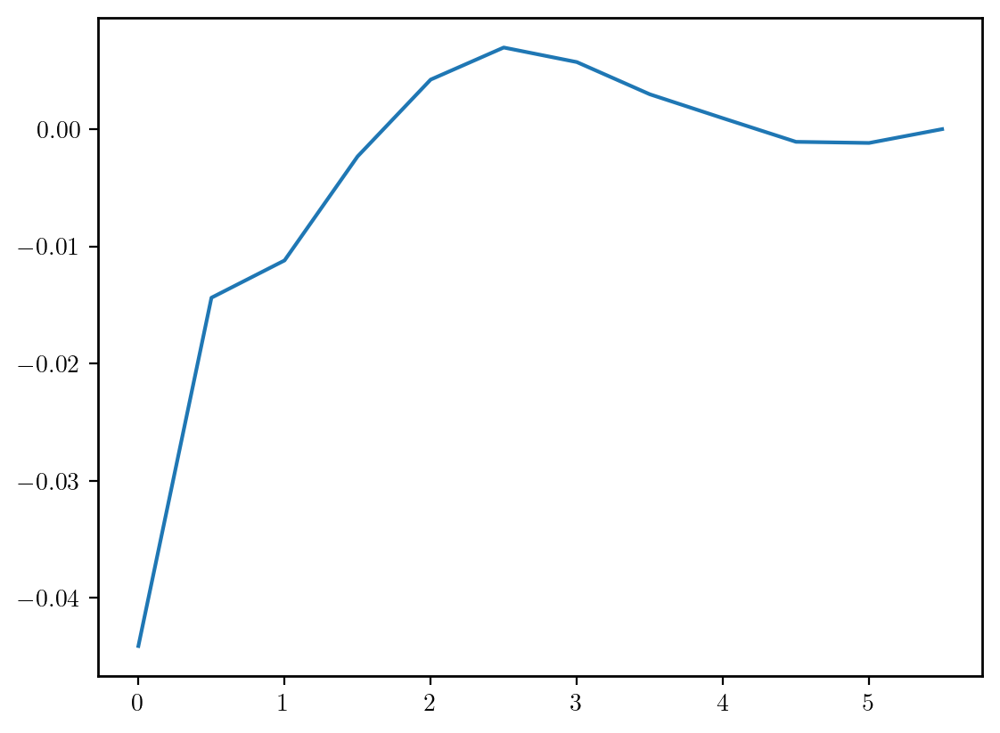

In [45]:
plt.plot(param, np.array(chi2-chi2[-1]))

# HALOFIT VS EE2

In [46]:
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=2):3.3f}")

/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/euclidemu2/ee2_bindata.dat
$\chi^2$=94.774
$\chi^2$=0.071


In [47]:
# HERE WE LEARN THAT FOR W(THETA), CAMB SHOULD HAVE ACCURACY BOOST=1.2
param = [1]
wtheta_theta = []
for x in param:
    wtheta_theta.append(nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2))
wtheta_theta_ref = nw.w_theta(ntheta=80,AccuracyBoost=1,CAMBAccuracyBoost=1.2,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

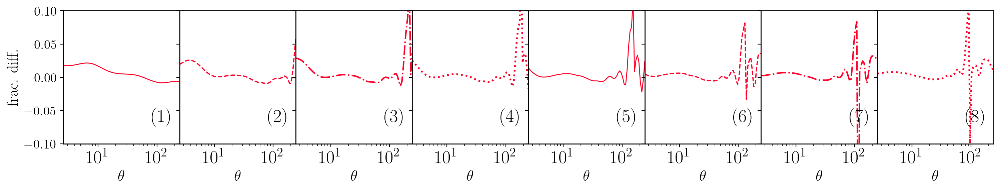

In [48]:
cnu.plot_wtheta_tomo(theta_wtheta=wtheta_theta,
                     theta_wtheta_ref=wtheta_theta_ref,
                     ylim = [0.9,1.1],
                     bintextpos = [0.85, 0.2],
                     param = param,
                     legendloc=(0.9,0.05),
                     linewidth=[1.0, 1.3, 1.6, 1.9],
                     linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
                     figsize = (18, 13./5),
                     bintextsize = 20,
                     yaxislabelsize = 17,
                     yaxisticklabelsize = 14,
                     xaxisticklabelsize = 20,
                     colorbar=None)